<a href="https://colab.research.google.com/github/hema1234-hub/titanic-data-set-/blob/main/online_shoppers_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving online_shoppers_intention.csv.zip to online_shoppers_intention.csv.zip


In [2]:
import zipfile
import pandas as pd

zip_name = next(iter(uploaded))
archive = zipfile.ZipFile(zip_name)

csv_names = [name for name in archive.namelist() if name.lower().endswith(".csv")]
print("CSV files found:", csv_names)

CSV files found: ['online_shoppers_intention.csv']


In [3]:
with archive.open(csv_names[0]) as csv_file:
    df = pd.read_csv(csv_file)

print("Dataset size:", df.shape)
df.head()

Dataset size: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Data types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Dataset information:
<class 'pandas.core.

In [5]:
print("Exact duplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

print("\nRevenue values:")
print(df["Revenue"].value_counts(dropna=False))

Exact duplicate rows: 125

Missing values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Revenue values:
Revenue
False    10422
True      1908
Name: count, dtype: int64


In [6]:
# Make a separate working copy
data = df.copy()

# Check the target labels and convert them to 0/1 for calculations
data["Revenue"] = data["Revenue"].astype(bool)
data["purchase"] = data["Revenue"].astype(int)

print("Purchase sessions:", data["purchase"].sum())
print("Non-purchase sessions:", (data["purchase"] == 0).sum())
print("Overall purchase rate (%):", round(data["purchase"].mean() * 100, 2))

Purchase sessions: 1908
Non-purchase sessions: 10422
Overall purchase rate (%): 15.47


In [7]:
numeric_columns = data.select_dtypes(include="number").columns.tolist()

# Exclude the purchase label from the behavior comparison
numeric_columns = [
    column for column in numeric_columns
    if column not in ["Revenue", "purchase"]
]

comparison = data.groupby("Revenue")[numeric_columns].mean().T
comparison.columns = ["No purchase", "Purchase"]

display(comparison.round(2))

,No purchase,Purchase
Administrative,2.12,3.39
Administrative_Duration,73.74,119.48
Informational,0.45,0.79
Informational_Duration,30.24,57.61
ProductRelated,28.71,48.21
ProductRelated_Duration,1069.99,1876.21
BounceRates,0.03,0.01
ExitRates,0.05,0.02
PageValues,1.98,27.26
SpecialDay,0.07,0.02


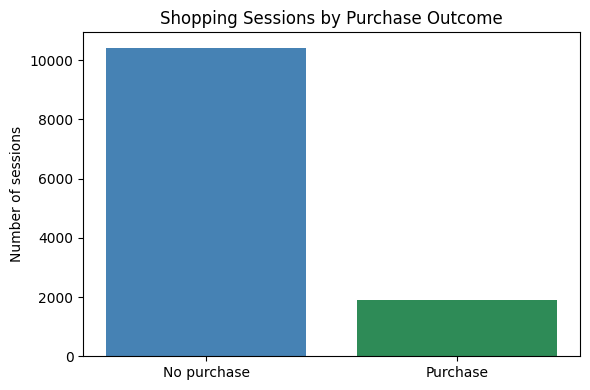

In [8]:
import matplotlib.pyplot as plt

purchase_counts = data["Revenue"].value_counts().reindex([False, True])

plt.figure(figsize=(6, 4))
plt.bar(
    ["No purchase", "Purchase"],
    purchase_counts.values,
    color=["steelblue", "seagreen"]
)
plt.title("Shopping Sessions by Purchase Outcome")
plt.ylabel("Number of sessions")
plt.tight_layout()
plt.show()

In [9]:
visitor_rates = data.groupby("VisitorType")["purchase"].agg(
    sessions="count",
    purchases="sum",
    purchase_rate="mean"
)

visitor_rates["purchase_rate_pct"] = visitor_rates["purchase_rate"] * 100

display(visitor_rates.sort_values("purchase_rate_pct", ascending=False).round(2))

,sessions,purchases,purchase_rate,purchase_rate_pct
VisitorType,,,,
New_Visitor,1694,422,0.25,24.91
Other,85,16,0.19,18.82
Returning_Visitor,10551,1470,0.14,13.93


In [10]:
month_rates = data.groupby("Month")["purchase"].agg(
    sessions="count",
    purchases="sum",
    purchase_rate="mean"
)

month_rates["purchase_rate_pct"] = month_rates["purchase_rate"] * 100

display(month_rates.sort_values("purchase_rate_pct", ascending=False).round(2))

,sessions,purchases,purchase_rate,purchase_rate_pct
Month,,,,
Nov,2998,760,0.25,25.35
Oct,549,115,0.21,20.95
Sep,448,86,0.19,19.20
Aug,433,76,0.18,17.55
Jul,432,66,0.15,15.28
Dec,1727,216,0.13,12.51
May,3364,365,0.11,10.85
June,288,29,0.10,10.07
Mar,1907,192,0.10,10.07


In [11]:
comparison["difference"] = comparison["Purchase"] - comparison["No purchase"]

display(
    comparison.reindex(
        comparison["difference"].abs().sort_values(ascending=False).index
    ).round(2).head(10)
)

,No purchase,Purchase,difference
ProductRelated_Duration,1069.99,1876.21,806.22
Administrative_Duration,73.74,119.48,45.74
Informational_Duration,30.24,57.61,27.38
PageValues,1.98,27.26,25.29
ProductRelated,28.71,48.21,19.50
Administrative,2.12,3.39,1.28
Informational,0.45,0.79,0.33
Browser,2.34,2.45,0.11
Region,3.16,3.08,-0.08
TrafficType,4.08,4.02,-0.06


In [12]:
print("Missing values per column:")
print(df.isna().sum())

print("\nExact duplicate rows:", df.duplicated().sum())
print("Dataset size:", df.shape)

Missing values per column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Exact duplicate rows: 125
Dataset size: (12330, 18)


In [13]:
print("Month values:", sorted(df["Month"].dropna().unique()))
print("Visitor types:", sorted(df["VisitorType"].dropna().unique()))
print("Revenue values:", df["Revenue"].value_counts(dropna=False))
print("Weekend values:", df["Weekend"].value_counts(dropna=False))

numeric_columns = df.select_dtypes(include="number").columns
print("\nNegative numeric values:")
print((df[numeric_columns] < 0).sum())

Month values: ['Aug', 'Dec', 'Feb', 'Jul', 'June', 'Mar', 'May', 'Nov', 'Oct', 'Sep']
Visitor types: ['New_Visitor', 'Other', 'Returning_Visitor']
Revenue values: Revenue
False    10422
True      1908
Name: count, dtype: int64
Weekend values: Weekend
False    9462
True     2868
Name: count, dtype: int64

Negative numeric values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
dtype: int64


In [14]:
clean_df = df.copy()
# Remove rows only when the purchase outcome is missing
clean_df = clean_df.dropna(subset=["Revenue"])
print("Original rows:", len(df))
print("Rows after this cleaning step:", len(clean_df))

Original rows: 12330
Rows after this cleaning step: 12330


In [15]:
clean_df["TotalPagesViewed"] = (
    clean_df["Administrative"]
    + clean_df["Informational"]
    + clean_df["ProductRelated"]
)
clean_df["TotalPageTime"] = (
    clean_df["Administrative_Duration"]
    + clean_df["Informational_Duration"]
    + clean_df["ProductRelated_Duration"]
)
clean_df[["TotalPagesViewed", "TotalPageTime", "Revenue"]].head()

,TotalPagesViewed,TotalPageTime,Revenue
0,1,0.000000,False
1,2,64.000000,False
2,1,0.000000,False
3,2,2.666667,False
4,10,627.500000,False
